## Robot Perception (Part 1)

### Introduction

This notebook will walk you through the process of 2D object detection and segmentation using deep learning approaches as opposed to traditional computer vision based approached explored in lesson 1.

Specifically, we are using the following tools, models, libraries:
- DL workflow tool: [Roboflow](https://roboflow.com/)
- DL model: [YOLOv11](https://blog.roboflow.com/what-is-yolo11/)



### Section 1: Image input

#### 1.0 Import relevant Python packages

In [1]:
from roboflow import Roboflow
import supervision as sv
import cv2
import matplotlib.pyplot as plt

#### 1.1 Load the image

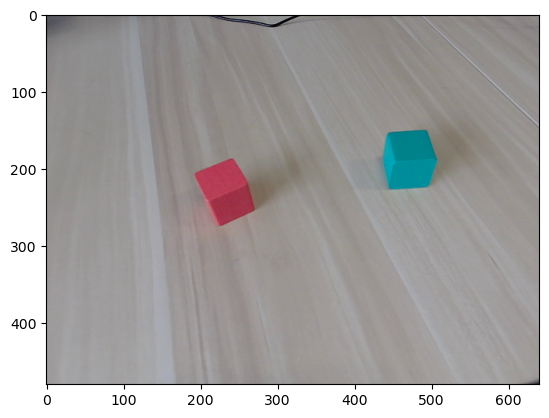

In [2]:
image_path = './img/img1.png'

# read the image from the directory
img = cv2.imread(image_path)

# Convert from BGR (OpenCV's default) to RGB (Matplotlib's default)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# display image
plt.imshow(img_rgb)
plt.show()

#### 1.2 Explore image properties

In [3]:
# TODO: Print the properties of the image (type, shape, size)

print('Image properties:')
print(f'Image type: {type(img_rgb)}')
print(f'Image shape: {img_rgb.shape}')
print(f'Image size: {img_rgb.size}')

Image properties:
Image type: <class 'numpy.ndarray'>
Image shape: (480, 640, 3)
Image size: 921600


### Section 2: Pretrained deep learning model

We are using a pretrained object detection and segmentation model built on **YOLOv11** through the Roboflow environment.

The model was specifically pretrained for colored block segmentation.
https://universe.roboflow.com/ender-pearl/block-segmentation-ofboy

<img src="img\block-seg-ofboy.png" width="500">

In [4]:
rf = Roboflow(api_key="RmDkhaQDgIJQgd76nVTR")
project = rf.workspace().project("block-segmentation-ofboy")
model = project.version(4).model

loading Roboflow workspace...
loading Roboflow project...


#### 2.1 Explore the model

In [5]:
print(f"Model description: {model}")
print(f"Model classes: {model.colors}")
print(f"Model ID: {model.id}")


Model description: <InstanceSegmentationModel id=kenechukwu-mbanisi/block-segmentation-ofboy/4, api_url=https://outline.roboflow.com/block-segmentation-ofboy/4>
Model classes: {'red': '#fc0000', 'yellow': '#f3ff00', 'orange': '#ff9900', 'purple': '#8300eb', 'green': '#16a30a', 'blue': '#0500ff'}
Model ID: kenechukwu-mbanisi/block-segmentation-ofboy/4


#### 2.2 Make a prediction on our data

In [6]:
# set the confidence threshold 
confidence_threshold = 90

result = model.predict(image_path, confidence=confidence_threshold).json()

#### 2.3 Explore the results

In [7]:
# the result object is a dictionary with keys
result.keys()

dict_keys(['predictions', 'image'])

In [8]:
# explore predictions
predictions = result["predictions"]
print(f"Number of predictions: {len(predictions)}")
predictions

Number of predictions: 2


[{'x': 232.0,
  'y': 232.0,
  'width': 76.0,
  'height': 88.0,
  'confidence': 0.9678687453269958,
  'class': 'red',
  'class_id': 4,
  'detection_id': '72937643-f332-4614-8451-5e6a75ff7bcd',
  'points': [{'x': 235.0, 'y': 188.25},
   {'x': 234.0, 'y': 189.0},
   {'x': 233.0, 'y': 189.0},
   {'x': 232.0, 'y': 189.75},
   {'x': 232.0, 'y': 190.5},
   {'x': 230.0, 'y': 192.0},
   {'x': 228.0, 'y': 192.0},
   {'x': 227.0, 'y': 192.75},
   {'x': 226.0, 'y': 192.75},
   {'x': 223.0, 'y': 195.0},
   {'x': 221.0, 'y': 195.0},
   {'x': 220.0, 'y': 195.75},
   {'x': 219.0, 'y': 195.75},
   {'x': 217.0, 'y': 197.25},
   {'x': 216.0, 'y': 197.25},
   {'x': 215.0, 'y': 198.0},
   {'x': 213.0, 'y': 198.0},
   {'x': 212.0, 'y': 198.75},
   {'x': 211.0, 'y': 198.75},
   {'x': 209.0, 'y': 200.25},
   {'x': 208.0, 'y': 200.25},
   {'x': 207.0, 'y': 201.0},
   {'x': 205.0, 'y': 201.0},
   {'x': 202.0, 'y': 203.25},
   {'x': 201.0, 'y': 203.25},
   {'x': 200.0, 'y': 204.0},
   {'x': 198.0, 'y': 204.0},
 

In [9]:
# See what class (labels) predictions were made
labels = [item["class"] for item in result["predictions"]]
labels

['red', 'green']

In [10]:
# filter predictions for a specific class, e.g., "red"
red_predictions = [pred for pred in result["predictions"] if pred["class"] == "red"]
red_predictions

[{'x': 232.0,
  'y': 232.0,
  'width': 76.0,
  'height': 88.0,
  'confidence': 0.9678687453269958,
  'class': 'red',
  'class_id': 4,
  'detection_id': '72937643-f332-4614-8451-5e6a75ff7bcd',
  'points': [{'x': 235.0, 'y': 188.25},
   {'x': 234.0, 'y': 189.0},
   {'x': 233.0, 'y': 189.0},
   {'x': 232.0, 'y': 189.75},
   {'x': 232.0, 'y': 190.5},
   {'x': 230.0, 'y': 192.0},
   {'x': 228.0, 'y': 192.0},
   {'x': 227.0, 'y': 192.75},
   {'x': 226.0, 'y': 192.75},
   {'x': 223.0, 'y': 195.0},
   {'x': 221.0, 'y': 195.0},
   {'x': 220.0, 'y': 195.75},
   {'x': 219.0, 'y': 195.75},
   {'x': 217.0, 'y': 197.25},
   {'x': 216.0, 'y': 197.25},
   {'x': 215.0, 'y': 198.0},
   {'x': 213.0, 'y': 198.0},
   {'x': 212.0, 'y': 198.75},
   {'x': 211.0, 'y': 198.75},
   {'x': 209.0, 'y': 200.25},
   {'x': 208.0, 'y': 200.25},
   {'x': 207.0, 'y': 201.0},
   {'x': 205.0, 'y': 201.0},
   {'x': 202.0, 'y': 203.25},
   {'x': 201.0, 'y': 203.25},
   {'x': 200.0, 'y': 204.0},
   {'x': 198.0, 'y': 204.0},
 

#### 2.4 Set the annotators (e.g., masking, bounding box, etc.)

Resources for annotators: https://supervision.roboflow.com/annotators

In [11]:
red_result = dict()
red_result["image"] = result["image"]
red_result["predictions"] = red_predictions

In [12]:
detections = sv.Detections.from_inference(red_result)

label_annotator = sv.LabelAnnotator()
mask_annotator = sv.MaskAnnotator(opacity=0.3)
bounding_box_annotator = sv.BoxAnnotator()
dot_annotator =sv.DotAnnotator(radius=12)


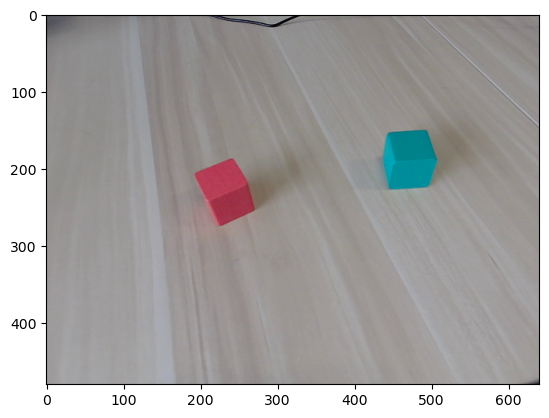

In [13]:
# # read the image from the directory
img = cv2.imread(image_path)

# # Convert from BGR (OpenCV's default) to RGB (Matplotlib's default)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# # display image
plt.imshow(img_rgb)
plt.show()

#### 2.5 Annotate the image

In [14]:
annotated_image = mask_annotator.annotate(
    scene=img_rgb, detections=detections)
annotated_image = bounding_box_annotator.annotate(
    scene=annotated_image, detections=detections)
annotated_image = dot_annotator.annotate(
    scene=annotated_image, detections=detections)

#### 2.6 Visualize the annotated image

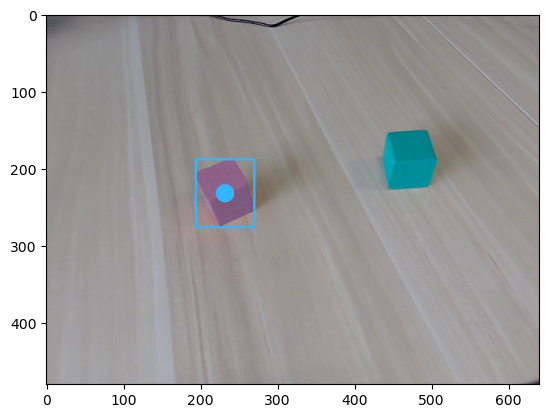

In [15]:
plt.imshow(annotated_image)
plt.show()

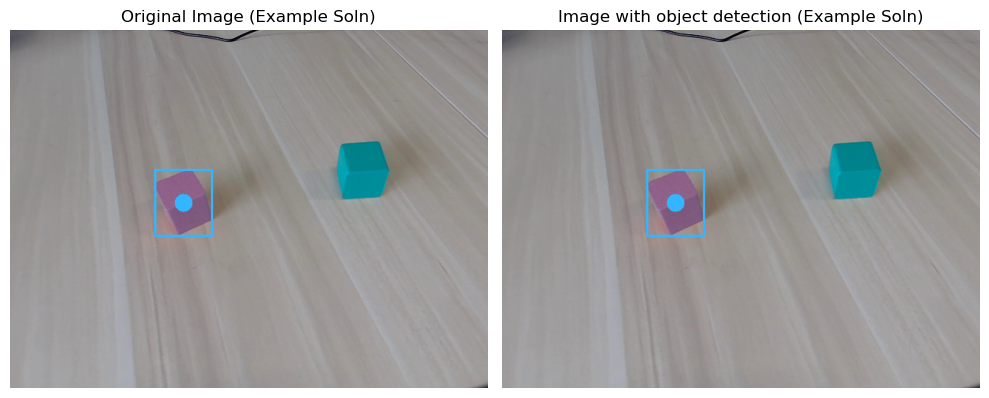

In [16]:
# # Plot the original image and the image with edges
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image (Example Soln)')
axes[0].axis('off')

axes[1].imshow(annotated_image)
axes[1].set_title('Image with object detection (Example Soln)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Example Solution

<img src="img\ex-solution2.png" width="800">


### Exercise
##### 1. Capture an image of your own with colored cubes in the workspace using the robot camera (connected to your laptop, for example). Use the [camera_capture.py](https://github.com/OlinCollege-FunRobo/funrobo_robot_perception/blob/main/camera_capture.py) script in the repo
##### 2. Perform object detection and segmentation for this image, select one cube color
##### 3. Export your work as a PDF (with all the cells executed and the results showing) and upload to Canvas
